# Using th Iris dataset to demonstrate SVM

In [1]:
# import libraries
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [8]:
# load the dataset
iris = load_iris()
X = iris.data
y = iris.target

print('Feature Shape: ', X.shape)
print('Target Shape: ', y.shape)

Feature Shape:  (150, 4)
Target Shape:  (150,)


In [13]:
# feature names
feature_names = iris.feature_names
print('Feature Names: ', feature_names)

Feature Names:  ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [14]:
# select two features for visualization
X_Vis = X[:, [0, 1]]
feature_X, feature_y = feature_names[0], feature_names[1]

In [15]:
# train test split
X_train, X_test, y_train, y_test = train_test_split(X_Vis, y, test_size=0.8, random_state=42)

In [16]:
# scale the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [17]:
# train the model
svc = SVC(kernel='linear', C=1.0, random_state=42)
svc.fit(X_train, y_train)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None


In [18]:
# evaluate the model
print('Training Accuracy:', svc.score(X_train, y_train))
print("Testing Accuracy:", svc.score(X_test, y_test))

Training Accuracy: 0.7666666666666667
Testing Accuracy: 0.7666666666666667


<Figure size 800x600 with 0 Axes>

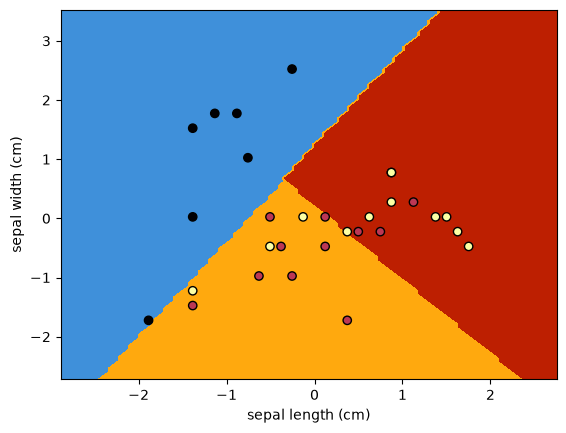

In [20]:
# plot the decision boundary
plt.figure(figsize=(8, 6))
DecisionBoundaryDisplay.from_estimator(
    svc, X_train, 
    response_method="predict", 
    xlabel=feature_X, 
    ylabel=feature_y
)
plt.scatter(
    X_train[:, 0], 
    X_train[:, 1], 
    c=y_train, 
    cmap=plt.cm.inferno, 
    edgecolor="k")